<a href="https://colab.research.google.com/github/RNKDevWorks/PROJECTS/blob/main/pythonProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


==== Smart Expense Tracker ====
1. Add Expense
2. View Monthly Summary
3. Exit
Enter choice: 1
Enter date (YYYY-MM-DD) or press Enter for today: 2026-01-18
Enter category (Food, Travel, Bills, etc.): food
Enter amount: 200
Enter description: Pani puri :)
✅ Expense added successfully!


==== Smart Expense Tracker ====
1. Add Expense
2. View Monthly Summary
3. Exit
Enter choice: 2
Enter month (YYYY-MM): 2026-01

📊 Total Expenses for 2026-01: ₹200.0

Category-wise Breakdown:
food: ₹200.0

🔥 Highest Spending Category: food (₹200.0)


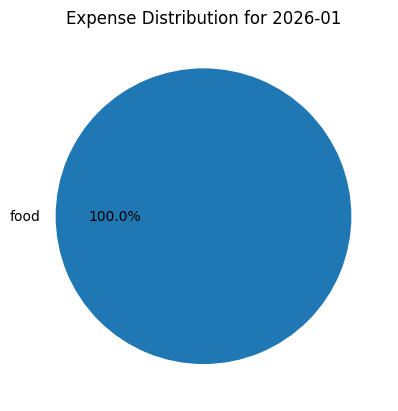


==== Smart Expense Tracker ====
1. Add Expense
2. View Monthly Summary
3. Exit


KeyboardInterrupt: Interrupted by user

In [1]:
import csv
import os
from datetime import datetime
import matplotlib.pyplot as plt

FILE_NAME = "expenses.csv"


def initialize_file():
    if not os.path.exists(FILE_NAME):
        with open(FILE_NAME, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(["Date", "Category", "Amount", "Description"])

# Add expense
def add_expense():
    date = input("Enter date (YYYY-MM-DD) or press Enter for today: ")
    if not date:
        date = datetime.now().strftime("%Y-%m-%d")

    category = input("Enter category (Food, Travel, Bills, etc.): ")
    amount = float(input("Enter amount: "))
    description = input("Enter description: ")

    with open(FILE_NAME, mode='a', newline='') as file:
        writer = csv.writer(file)
        writer.writerow([date, category, amount, description])

    print("✅ Expense added successfully!\n")

# Read expenses
def read_expenses():
    expenses = []
    with open(FILE_NAME, mode='r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            expenses.append({
                "date": row["Date"],
                "category": row["Category"],
                "amount": float(row["Amount"]),
                "description": row["Description"]
            })
    return expenses

# Monthly summary
def monthly_summary():
    month = input("Enter month (YYYY-MM): ")
    expenses = read_expenses()

    total = 0
    category_totals = {}

    for expense in expenses:
        if expense["date"].startswith(month):
            total += expense["amount"]
            category = expense["category"]

            if category in category_totals:
                category_totals[category] += expense["amount"]
            else:
                category_totals[category] = expense["amount"]

    print(f"\n📊 Total Expenses for {month}: ₹{total}")

    print("\nCategory-wise Breakdown:")
    for cat, amt in category_totals.items():
        print(f"{cat}: ₹{amt}")

    # Highest spending category
    if category_totals:
        highest = max(category_totals, key=category_totals.get)
        print(f"\n🔥 Highest Spending Category: {highest} (₹{category_totals[highest]})")

    # Pie chart
    if category_totals:
        plt.figure()
        plt.pie(category_totals.values(), labels=category_totals.keys(), autopct='%1.1f%%')
        plt.title(f"Expense Distribution for {month}")
        plt.show()

# Menu
def menu():
    initialize_file()

    while True:
        print("\n==== Smart Expense Tracker ====")
        print("1. Add Expense")
        print("2. View Monthly Summary")
        print("3. Exit")

        choice = input("Enter choice: ")

        if choice == "1":
            add_expense()
        elif choice == "2":
            monthly_summary()
        elif choice == "3":
            print("Goodbye!")
            break
        else:
            print("Invalid choice. Try again.")

if __name__ == "__main__":
    menu()